In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#Zdefiniowanie baz pomiarowych
b0 = np.array([1, 0]) # |0>
b1 = np.array([0, 1]) # |1>
b2 = np.array([1/math.sqrt(2), 1/math.sqrt(2)]) # |+>
b3 = np.array([1/math.sqrt(2), -1j/math.sqrt(2)]) # |-i> - nie pamietam czy + czy - i teraz xdd

b = [b0, b1, b2, b3]

#Zdefiniowanie bazy macierzy gestosci
g0 = np.array([[1, 0], [0, 1]]) #jednostkowa
g1 = np.array([[0, 1], [1, 0]]) #sigma x
g2 = np.array([[0, -1j], [1j, 0]]) #sigma y 
g3 = np.array([[1, 0], [0, -1]]) #sigma z

g = [g0, g1, g2, g3]

def printcircuits(circuits_temp):
    for i in circuits_temp:
        i.draw(output='mpl')
        plt.show()

In [5]:
#Rozszerzenie bazy na N qubitow
from itertools import product

N = 2  # liczba qubitow

b_big = []              # pełne wektory N-qubitowe
g_big = []              # pelne macierze N-qubitowe
structure = []          # zapis struktury (które stany 1q tworzą dany stan)

#Stworzenie wszystkich kombinacji stanów z bazy żeby była pełna przestrzeń N qubitowa
for combo_indices in product(range(len(b)), repeat=N):

    # zapisz strukturę (np. (0,3)) - tu jest tworzenie obiektu ktory trzyma info o małych wektorach budujących dany duzy wektor
    structure.append(combo_indices)

    # pierwszy czynnik
    result_b = b[combo_indices[0]]
    result_g = g[combo_indices[0]]

    # kolejne czynniki tensora - zwyczajny iloczyn tensorowy zeby powiekszyc przestrzen odpowiednimi malymi wektorami/macierzami
    for idx in combo_indices[1:]:
        result_b = np.kron(result_b, b[idx])
        result_g = np.kron(result_g, g[idx])

    b_big.append(result_b)
    g_big.append(result_g)

m = np.zeros(len(structure))
b_big = np.array(b_big)
g_big = np.array(g_big)
print(b_big.shape)
print(g_big.shape)

(16, 4)
(16, 4, 4)


In [7]:
#Wyliczenie macierzy B oraz jej odwrócenie
B = np.zeros((b_big.shape[0], b_big.shape[0]), dtype=complex)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        B[i, j] = np.conjugate(b_big[i]).T @ g_big[j] @ b_big[i]

print(B)

B_inv = np.linalg.inv(B)

print(B_inv)

[[ 1.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  1.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 1.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j  1.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 1.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  1.+0.j]
 [ 1.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
   0.+0.j  0.+0.j  0.+0.j -1.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [ 1.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.

In [9]:
#Odczyt z plikow
#Wczytuje wyniki pomiarow, uklady przed i po transpilacji
import glob
from pathlib import Path
import qiskit.qpy as qpy
from qiskit.circuit import Delay

#Tutaj sie podaje numer plikow w folderze i folder
numer = "1"
folder = "Runs_2026-04-15"

file1 = list(Path(folder).glob(f"{numer}_circuits_*.qpy"))[0]
file2 = list(Path(folder).glob(f"{numer}_circuitsraw_*.qpy"))[0]
file3 = list(Path(folder).glob(f"{numer}_counts_*.json"))[0]

circuits = []
circuits_untranspiled = []
all_counts = []



with open(file1, "rb") as f:
    circuits = qpy.load(f) #wczytuje, ale wszystkie opoznienia sa 0dt, trzeba z drugiego circuits patrzec
with open(file2, "rb") as f:
    circuits_untranspiled = qpy.load(f)
with open(file3) as f:
    all_counts = json.load(f)

m_full = np.zeros(len(all_counts))
        
for i in range(len(all_counts)):
    counts = all_counts[i]
    zero_state = '0' * N
    m_full[i] = counts.get(zero_state, 0) / sum(counts.values())

print(m_full)

[0.436 0.049 0.269 0.254 0.052 0.431 0.278 0.231 0.264 0.26  0.043 0.249
 0.225 0.257 0.244 0.431 0.496 0.141 0.323 0.294 0.121 0.28  0.217 0.192
 0.282 0.206 0.117 0.249 0.303 0.217 0.255 0.407 0.53  0.174 0.335 0.348
 0.123 0.161 0.181 0.168 0.316 0.188 0.159 0.268 0.331 0.185 0.241 0.344
 0.634 0.175 0.429 0.383 0.108 0.082 0.111 0.098 0.386 0.12  0.229 0.24
 0.389 0.127 0.27  0.266]


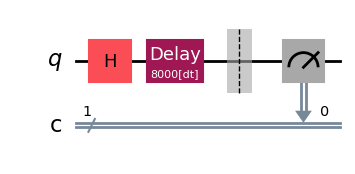

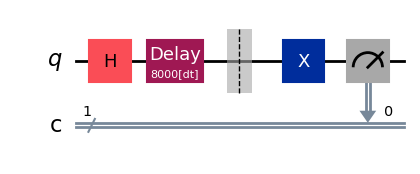

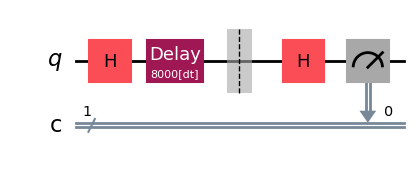

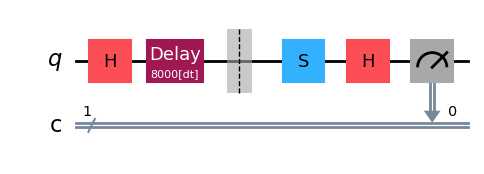

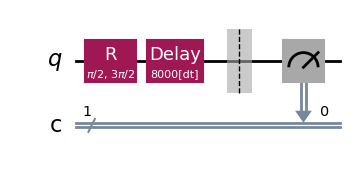

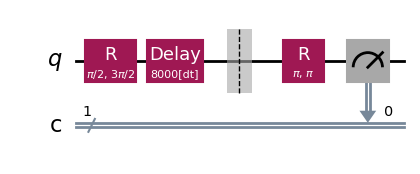

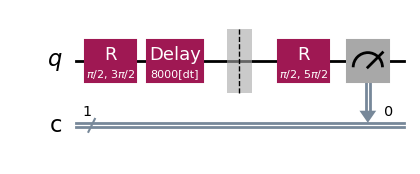

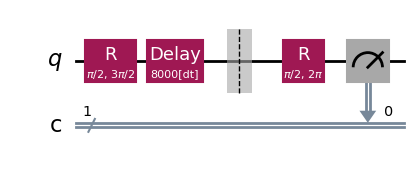

In [81]:
printcircuits(circuits_untranspiled)
printcircuits(circuits)

In [23]:
#Wziecie odpowiednich wynikow pomiarow z m_full do m
A = 3 #Tutaj wpisanie ktory blok
for i in range(len(m)):
    m[i] = m_full[i+A*len(m)]

print(m)

[0.634 0.175 0.429 0.383 0.108 0.082 0.111 0.098 0.386 0.12  0.229 0.24
 0.389 0.127 0.27  0.266]


In [25]:
#Rekonstrukcja rho
rho = np.zeros((2**N, 2**N), dtype=complex)
for i in range(g_big.shape[0]):
    rho += g_big[i] * (B_inv @ m)[i]

print(rho)

[[ 0.634 +0.j      0.0245-0.0215j  0.015 +0.018j  -0.0615-0.012j ]
 [ 0.0245+0.0215j  0.175 +0.j     -0.027 -0.0045j -0.0085-0.0015j]
 [ 0.015 -0.018j  -0.027 +0.0045j  0.108 +0.j      0.016 +0.003j ]
 [-0.0615+0.012j  -0.0085+0.0015j  0.016 -0.003j   0.082 +0.j    ]]


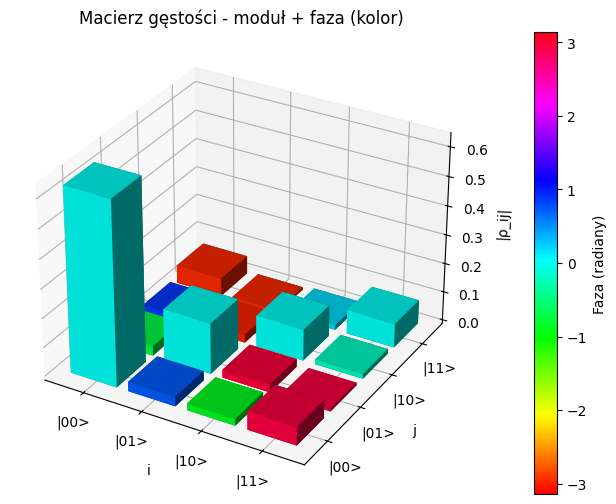

In [27]:
#Narysowanie rho
import matplotlib.pyplot as plt
from matplotlib import cm

n = rho.shape[0]
x = []
y = []
heights = []
colors = []

for i in range(n):
    for j in range(n):
        x.append(i)
        y.append(j)
        heights.append(np.abs(rho[i,j]))
        colors.append(np.angle(rho[i,j]))


# normalizacja fazy -π..π -> 0..1 dla cmap
norm_colors = (np.array(colors) + np.pi) / (2*np.pi)

# wykres 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

bars = ax.bar3d(x, y, np.zeros_like(heights), 0.8, 0.8, heights, color=cm.hsv(norm_colors))

# etykiety osi (stany bazowe)
labels = [f"|{format(i, f'0{N}b')}>"
          for i in range(n)]
ax.set_xticks(np.arange(n) + 0.4)
ax.set_xticklabels(labels)
ax.set_yticks(np.arange(n) + 0.4)
ax.set_yticklabels(labels)

ax.set_xlabel('i')
ax.set_ylabel('j')
ax.set_zlabel('|ρ_ij|')
ax.set_title('Macierz gęstości - moduł + faza (kolor)')

# dodanie legendy fazy
sm = plt.cm.ScalarMappable(cmap=cm.hsv, norm=plt.Normalize(vmin=-np.pi, vmax=np.pi))
cbar = fig.colorbar(sm, ax=ax, pad=0.1)
cbar.set_label('Faza (radiany)')

plt.show()